# FashionMNIST Image Classifier with PyTorch

This notebook ties together the helper modules in this folder:

| Step | File | Function(s) |
|---|---|---|
| 0. Hardware check | `hardware_check.py` | `get_device()` |
| 1. Train / validation / test split | `fashion_split.py` | `load_fashion_mnist_splits()` |
| 2. Preprocessing | `fashion_preprocess.py` | `preprocess_splits()` |
| 3. Mini-batch DataLoaders | `fashion_dataloaders.py` | `get_dataloaders()` |
| 4. Build & train the CNN | `fashion_train.py` | `FashionCNN`, `train_model()`, `plot_accuracy()` |
| 5. Test-set evaluation | `fashion_evaluate.py` | `evaluate_model()` |

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch

from hardware_check import get_device
from fashion_split import load_fashion_mnist_splits
from fashion_preprocess import preprocess_splits
from fashion_dataloaders import get_dataloaders
from fashion_train import FashionCNN, train_model, plot_accuracy
from fashion_evaluate import evaluate_model

## 0. Hardware check
Pick the best available device: CUDA (NVIDIA GPU), MPS (Apple Silicon) or CPU.

In [2]:
device = get_device()

PyTorch version: 2.14.0+cu130
Using device: CPU


## 1. Split the dataset
The 60,000 official training images are split into **55,000 train** and **5,000 validation** images (seed 42).
The official **10,000 test** images are kept untouched for the final evaluation.

In [3]:
train_data, valid_data, test_data = load_fashion_mnist_splits()
class_names = test_data.classes
print(f"train: {len(train_data)}, valid: {len(valid_data)}, test: {len(test_data)}")
print("classes:", class_names)

train: 55000, valid: 5000, test: 10000
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


Let's look at some training images:

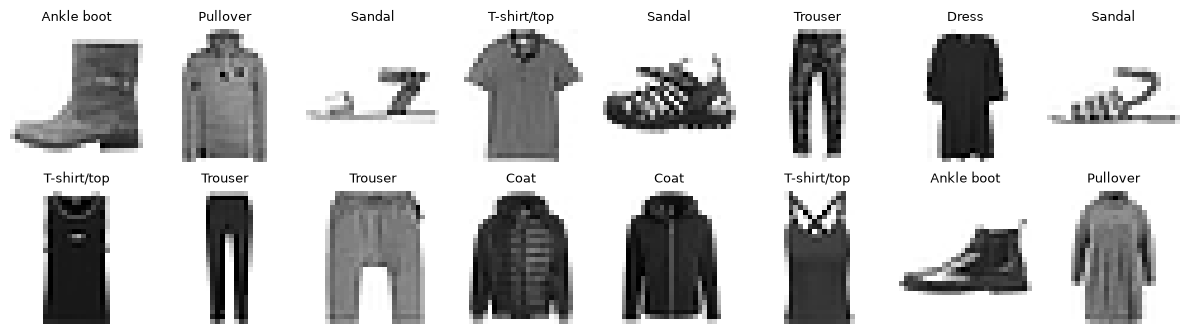

In [4]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, idx in zip(axes.flat, range(16)):
    X, y = train_data[idx]
    ax.imshow(X.squeeze(), cmap="binary")
    ax.set_title(class_names[y], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Preprocessing
- **Standardization**: pixels are scaled with the *training-set* mean and std, which makes optimization faster and more stable.
- **Data augmentation** (train only): random horizontal flips give the model more varied examples and reduce overfitting.

In [5]:
train_pp, valid_pp, test_pp, (mean, std) = preprocess_splits(train_data, valid_data, test_data)
print(f"training pixel mean: {mean:.4f}, std: {std:.4f}")
X_sample = torch.stack([valid_pp[i][0] for i in range(1000)])
print(f"validation sample after standardization: mean={X_sample.mean():.3f}, std={X_sample.std():.3f}")

training pixel mean: 0.2856, std: 0.3527
validation sample after standardization: mean=0.016, std=1.007


## 3. DataLoaders
`get_dataloaders()` runs steps 1 and 2 and wraps each split in a `DataLoader` (batch size 128, shuffling only for training).

In [6]:
train_loader, valid_loader, test_loader, class_names = get_dataloaders(batch_size=128)
X_batch, y_batch = next(iter(train_loader))
print(f"batches -> train: {len(train_loader)}, valid: {len(valid_loader)}, test: {len(test_loader)}")
print(f"X batch: {tuple(X_batch.shape)} {X_batch.dtype} | y batch: {tuple(y_batch.shape)} {y_batch.dtype}")

batches -> train: 430, valid: 40, test: 79
X batch: (128, 1, 28, 28) torch.float32 | y batch: (128,) torch.int64


## 4. Build and train the model
`FashionCNN` has two convolutional blocks (conv → batchnorm → ReLU ×2, then max-pool) followed by a dropout-regularized dense classifier.

Training uses cross-entropy loss and Adam; the learning rate is halved when validation accuracy plateaus,
and the returned model keeps the weights of the epoch with the **best validation accuracy**.

In [7]:
print(FashionCNN())

FashionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, strid

In [8]:
model, history = train_model(train_loader, valid_loader, n_epochs=15, lr=1e-3, device=device)

Epoch  1/15 | train loss 0.4592 acc 0.8332 | valid loss 0.3005 acc 0.8862


Epoch  2/15 | train loss 0.3094 acc 0.8878 | valid loss 0.2593 acc 0.9008


Epoch  3/15 | train loss 0.2731 acc 0.9008 | valid loss 0.2401 acc 0.9056


Epoch  4/15 | train loss 0.2505 acc 0.9081 | valid loss 0.2567 acc 0.9022


Epoch  5/15 | train loss 0.2367 acc 0.9144 | valid loss 0.2201 acc 0.9198


...

Epoch 11/15 | train loss 0.1773 acc 0.9349 | valid loss 0.1880 acc 0.9314


Epoch 12/15 | train loss 0.1705 acc 0.9376 | valid loss 0.1894 acc 0.9320


Epoch 13/15 | train loss 0.1617 acc 0.9398 | valid loss 0.1786 acc 0.9322


Epoch 14/15 | train loss 0.1395 acc 0.9484 | valid loss 0.1746 acc 0.9392


Epoch 15/15 | train loss 0.1333 acc 0.9509 | valid loss 0.1707 acc 0.9378

Final (last epoch)  -> train loss 0.1333, train acc 0.9509, valid loss 0.1707, valid acc 0.9378
Best model (epoch 14) -> valid loss 0.1746, valid acc 0.9392  (these weights are returned)


### Train vs. validation accuracy per epoch

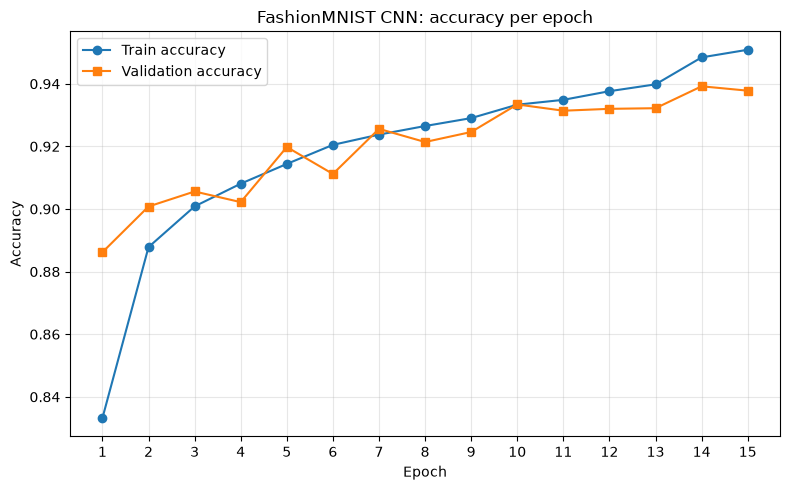

In [9]:
plot_accuracy(history)

## 5. Evaluate on the test set

In [10]:
test_loss, test_acc = evaluate_model(model, test_loader, class_names)

Test loss: 0.1822 | Test accuracy: 0.9342
Accuracy per class:
  T-shirt/top  0.8650
  Trouser      0.9910
  Pullover     0.8980
  Dress        0.9590
  Coat         0.9150
  Sandal       0.9850
  Shirt        0.7920
  Sneaker      0.9760
  Bag          0.9870
  Ankle boot   0.9740


Save the trained weights so the model can be reloaded later without retraining:

In [11]:
torch.save(model.state_dict(), "fashion_cnn.pt")

# To reload:
# model = FashionCNN().to(device)
# model.load_state_dict(torch.load("fashion_cnn.pt", map_location=device))